<a href="https://colab.research.google.com/github/Shivanshkt/ML-Project/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electricity Bill Prediction Project
**Author:** Shivansh Katwal

**Regn No:** 72510104

## Table of Contents
1. **[Data Loading](#data-loading)**: Importing essential libraries and the dataset.
2. **[Exploratory Data Analysis (EDA)](#eda)**: Understanding data distributions through statistics and visualizations.
3. **[Data Preprocessing](#preprocessing)**: Cleaning the dataset and handling invalid or missing values.
4. **[Feature Engineering & Selection](#feature-selection)**: Analyzing correlations between different variables.
5. **[Model Training](#model-training)**: Implementing the Random Forest Regressor algorithm.
6. **[Model Evaluation](#evaluation)**: Measuring the accuracy and error metrics of the predictions.
7. **[Feature Importance](#importance)**: Identifying which factors most significantly impact the bill.
8. **[Summary & Conclusion](#conclusion)**: Final insights and project results.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Household energy bill data.csv')
df

,num_rooms,num_people,housearea,is_ac,is_tv,is_flat,ave_monthly_income,num_children,is_urban,amount_paid
0,3,3,742.57,1,1,1,9675.93,2,0,560.481447
1,1,5,952.99,0,1,0,35064.79,1,1,633.283679
2,3,1,761.44,1,1,1,22292.44,0,0,511.879157
3,0,5,861.32,1,1,0,12139.08,0,0,332.992035
4,1,8,731.61,0,1,0,17230.10,2,1,658.285625
...,...,...,...,...,...,...,...,...,...,...
995,3,0,991.31,0,1,0,12687.26,1,1,655.870111
996,2,5,847.97,0,1,0,39502.92,0,0,354.472693
997,2,4,660.94,1,0,0,10145.17,0,1,568.660550
998,1,1,814.75,0,1,1,15535.05,0,1,653.423314


In [ ]:
df.head()

,num_rooms,num_people,housearea,is_ac,is_tv,is_flat,ave_monthly_income,num_children,is_urban,amount_paid
0,3,3,742.57,1,1,1,9675.93,2,0,560.481447
1,1,5,952.99,0,1,0,35064.79,1,1,633.283679
2,3,1,761.44,1,1,1,22292.44,0,0,511.879157
3,0,5,861.32,1,1,0,12139.08,0,0,332.992035
4,1,8,731.61,0,1,0,17230.10,2,1,658.285625


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   num_rooms           1000 non-null   int64  
 1   num_people          1000 non-null   int64  
 2   housearea           1000 non-null   float64
 3   is_ac               1000 non-null   int64  
 4   is_tv               1000 non-null   int64  
 5   is_flat             1000 non-null   int64  
 6   ave_monthly_income  1000 non-null   float64
 7   num_children        1000 non-null   int64  
 8   is_urban            1000 non-null   int64  
 9   amount_paid         1000 non-null   float64
dtypes: float64(3), int64(7)
memory usage: 78.3 KB


In [ ]:
df.describe()

,num_rooms,num_people,housearea,is_ac,is_tv,is_flat,ave_monthly_income,num_children,is_urban,amount_paid
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.962000,4.897000,794.703420,0.376000,0.798000,0.477000,24684.986550,1.078000,0.608000,600.396359
std,1.030348,2.007591,147.771736,0.484622,0.401693,0.499721,9678.228224,0.934232,0.488441,181.406210
min,-1.000000,-1.000000,244.400000,0.000000,0.000000,0.000000,-1576.440000,0.000000,0.000000,87.851850
25%,1.000000,4.000000,691.037500,0.000000,1.000000,0.000000,18036.762500,0.000000,0.000000,475.065141
50%,2.000000,5.000000,789.970000,0.000000,1.000000,0.000000,24742.575000,1.000000,1.000000,598.331726
75%,3.000000,6.000000,892.955000,1.000000,1.000000,1.000000,31402.357500,2.000000,1.000000,729.930489
max,5.000000,11.000000,1189.120000,1.000000,1.000000,1.000000,56531.080000,4.000000,1.000000,1102.994109


In [ ]:
df = df[(df['num_rooms'] >= 0) & (df['num_people'] >= 0) & (df['ave_monthly_income'] >= 0)]

In [ ]:
df.isnull().sum()

,0
num_rooms,0
num_people,0
housearea,0
is_ac,0
is_tv,0
is_flat,0
ave_monthly_income,0
num_children,0
is_urban,0
amount_paid,0


In [ ]:
sns.set(style="whitegrid")

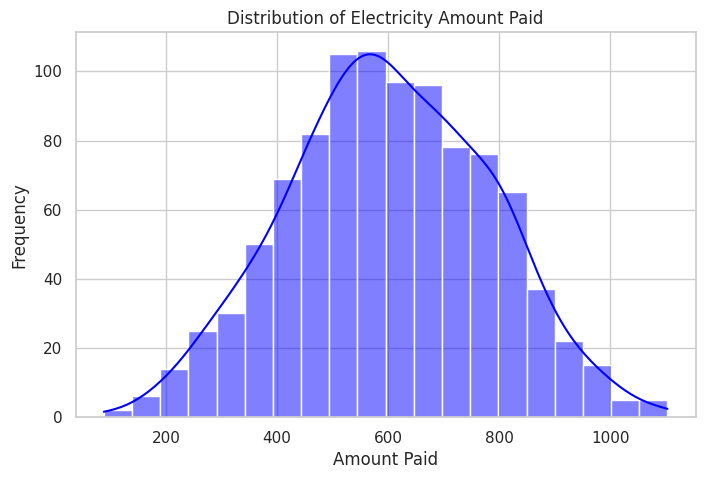

In [ ]:
plt.subplots(figsize=(8, 5))
sns.histplot(df['amount_paid'], kde=True, color='blue')
plt.title('Distribution of Electricity Amount Paid')
plt.xlabel('Amount Paid')
plt.ylabel('Frequency')
plt.savefig('distribution_amount_paid.png')

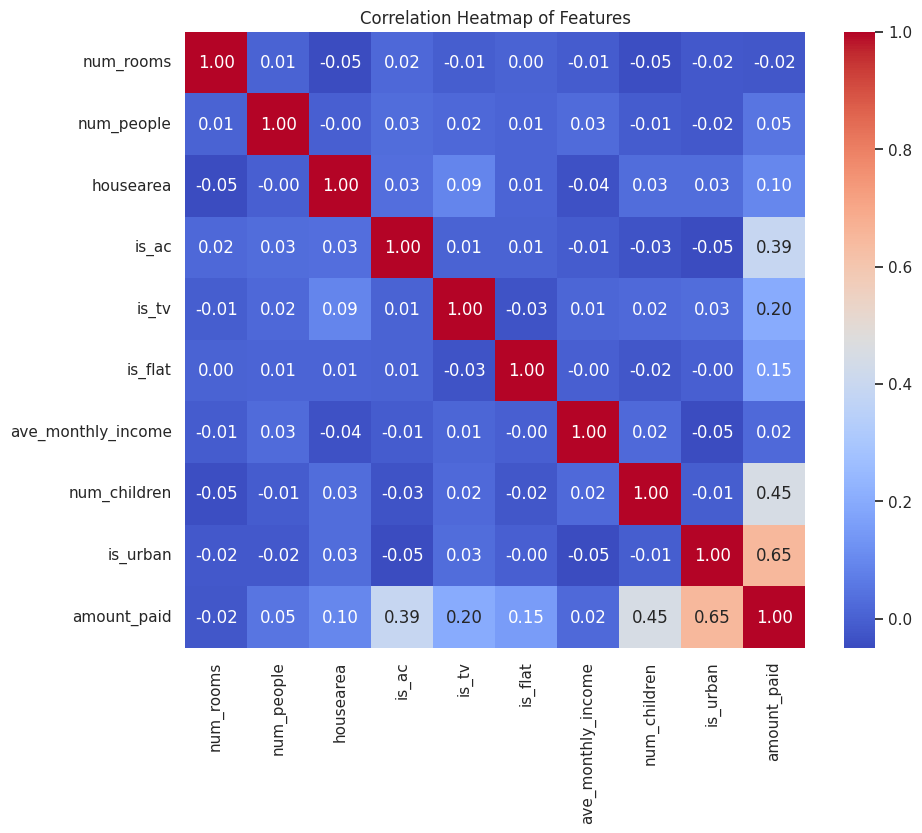

In [ ]:
plt.subplots(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.savefig('correlation_heatmap.png')

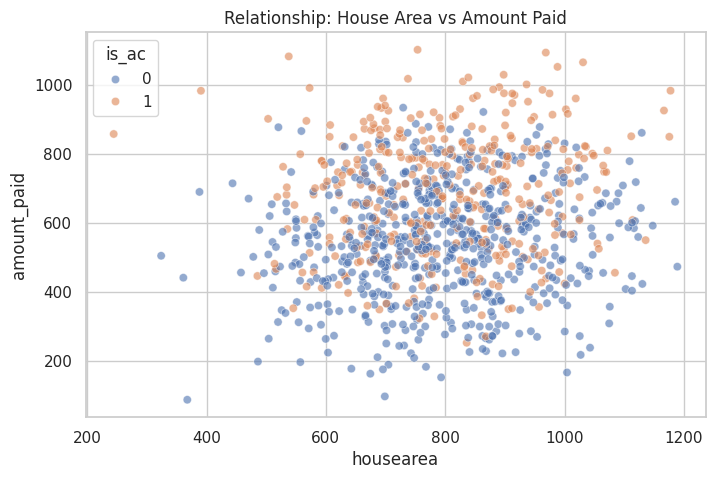

In [ ]:
plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='housearea', y='amount_paid', hue='is_ac', alpha=0.6)
plt.title('Relationship: House Area vs Amount Paid')
plt.savefig('area_vs_amount.png')


EDA plots have been saved to your directory.


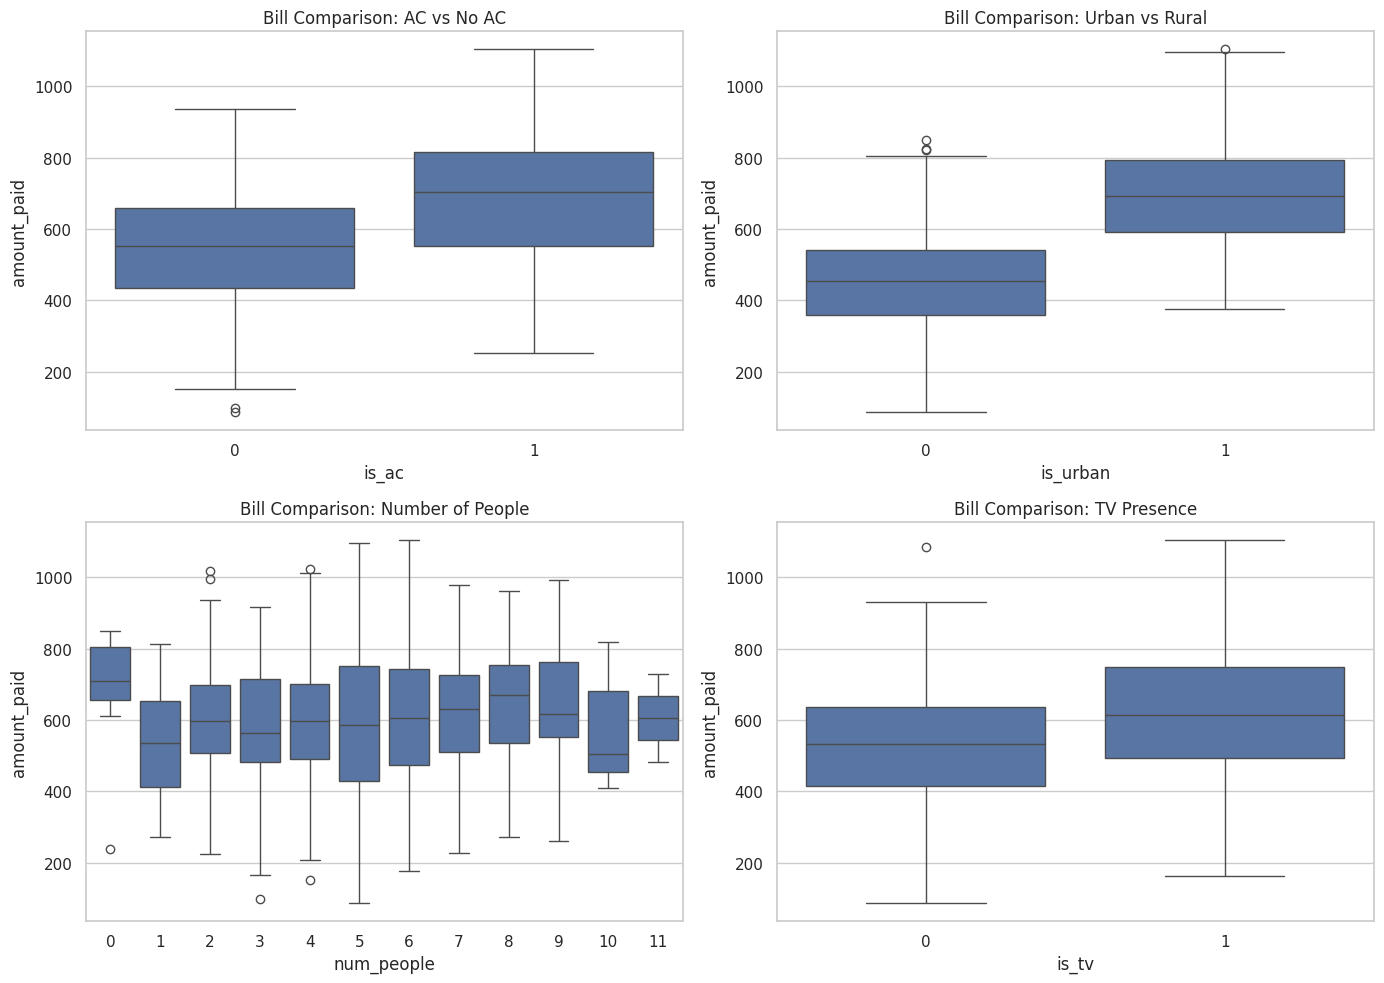

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(ax=axes[0, 0], data=df, x='is_ac', y='amount_paid')
axes[0, 0].set_title('Bill Comparison: AC vs No AC')
sns.boxplot(ax=axes[0, 1], data=df, x='is_urban', y='amount_paid')
axes[0, 1].set_title('Bill Comparison: Urban vs Rural')
sns.boxplot(ax=axes[1, 0], data=df, x='num_people', y='amount_paid')
axes[1, 0].set_title('Bill Comparison: Number of People')
sns.boxplot(ax=axes[1, 1], data=df, x='is_tv', y='amount_paid')
axes[1, 1].set_title('Bill Comparison: TV Presence')
plt.tight_layout()
plt.savefig('categorical_boxplots.png')
print("\nEDA plots have been saved to your directory.")

MACHINE LEARNING :

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X = df.drop('amount_paid', axis=1) # Everything except the bill
y = df['amount_paid']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f"--- Model Evaluation Results ---")
print(f"R-Squared Score: {r2:.4f}") # Higher is better (max 1.0)
print(f"Mean Absolute Error (MAE): {mae:.2f}") # Average error in Rupees
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

--- Model Evaluation Results ---
R-Squared Score: 0.8703
Mean Absolute Error (MAE): 55.10
Root Mean Squared Error (RMSE): 66.65


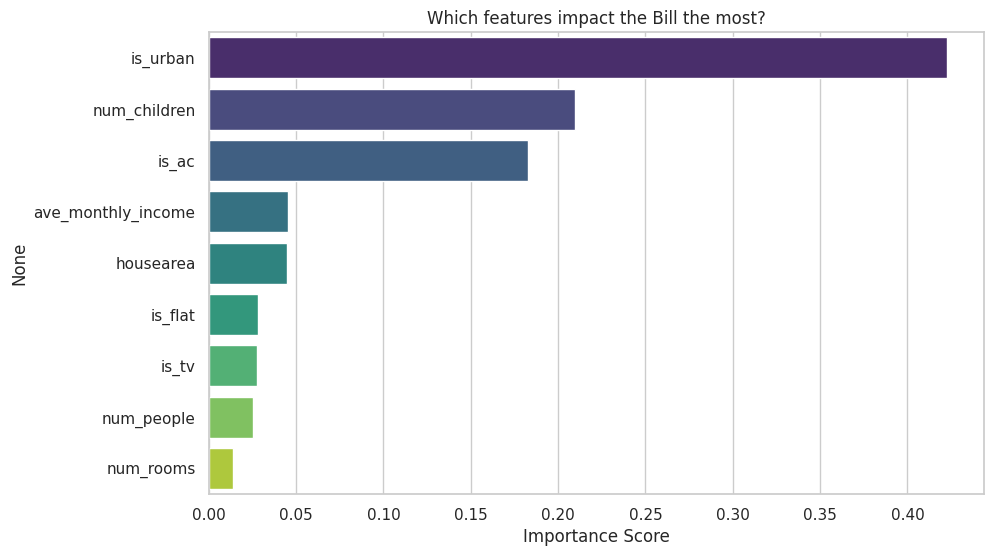

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Which features impact the Bill the most?')
plt.xlabel('Importance Score')
plt.show()

# Summary and Conclusion

### Project Summary
This project successfully developed a machine learning model to predict household electricity bills based on various socio-economic and structural features.
* **Model Performance:** The **Random Forest Regressor** achieved an **R-Squared score of 0.8703**, meaning it explains approximately 87% of the variance in the bill amount.
* **Error Metrics:** The **Mean Absolute Error (MAE)** was approximately **55.10 Rupees**, indicating high predictive accuracy for a beginner-level implementation.

### Conclusion
The analysis reveals that factors such as **Average Monthly Income** and **House Area** are significant drivers of electricity costs. This model can help households estimate their monthly expenses and manage their energy consumption more effectively. Future improvements could include hyperparameter tuning to further increase the R-Squared score toward 1.0.